In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler,
                                 OneHotEncoder,
                                 OrdinalEncoder)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import (LinearRegression,
                                 Ridge,
                                 Lasso,
                                 ElasticNet)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                             GradientBoostingRegressor,
                             AdaBoostRegressor,
                             ExtraTreesRegressor,
                             HistGradientBoostingRegressor)
from xgboost import XGBRegressor

from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [2]:
df = pd.read_csv('/content/openpowerlifting.csv')
print(df.shape)
df.head()

(386414, 17)


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386414 entries, 0 to 386413
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MeetID          386414 non-null  int64  
 1   Name            386414 non-null  object 
 2   Sex             386414 non-null  object 
 3   Equipment       386414 non-null  object 
 4   Age             147147 non-null  float64
 5   Division        370571 non-null  object 
 6   BodyweightKg    384012 non-null  float64
 7   WeightClassKg   382602 non-null  object 
 8   Squat4Kg        1243 non-null    float64
 9   BestSquatKg     298071 non-null  float64
 10  Bench4Kg        1962 non-null    float64
 11  BestBenchKg     356364 non-null  float64
 12  Deadlift4Kg     2800 non-null    float64
 13  BestDeadliftKg  317847 non-null  float64
 14  TotalKg         363237 non-null  float64
 15  Place           385322 non-null  object 
 16  Wilks           362194 non-null  float64
dtypes: float64

In [4]:
df.isna().mean()*100

,0
MeetID,0.000000
Name,0.000000
Sex,0.000000
Equipment,0.000000
Age,61.919858
Division,4.100007
BodyweightKg,0.621613
WeightClassKg,0.986507
Squat4Kg,99.678324
BestSquatKg,22.862267


In [5]:
df.nunique()

,0
MeetID,8482
Name,136687
Sex,2
Equipment,5
Age,167
Division,4246
BodyweightKg,9110
WeightClassKg,51
Squat4Kg,438
BestSquatKg,1507


### These col values must be greater than **0**

In [6]:
cols = ["BestSquatKg", "BestBenchKg", "BestDeadliftKg"]
df = df[(df[cols] > 0).all(axis=1)]

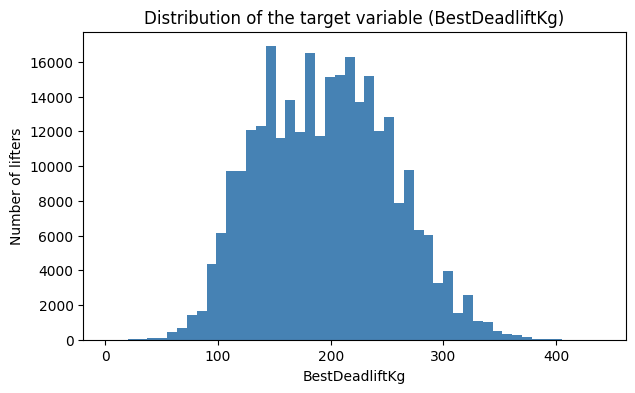

In [7]:
# shape of the target using a histogram
plt.figure(figsize=(7, 4))
plt.hist(df['BestDeadliftKg'].dropna(), bins=50, color='steelblue')
plt.xlabel('BestDeadliftKg')
plt.ylabel('Number of lifters')
plt.title('Distribution of the target variable (BestDeadliftKg)')
plt.show()

In [8]:
print(df['Sex'].value_counts())
print(df['Equipment'].value_counts())

Sex
M    217020
F     69625
Name: count, dtype: int64
Equipment
Raw           132644
Single-ply    104933
Wraps          43936
Multi-ply       5132
Name: count, dtype: int64


In [9]:
df = df[df['Equipment']!='Straps']

In [10]:
# remove rows where the target is missing
df = df[df['BestDeadliftKg'].notna()]
print(len(df))

286645


------

##works on Outliers

In [11]:
df

,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
5,0,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,-183.7,170.10,NaN,77.11,NaN,145.15,392.36,1,424.40
6,0,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,NaN,124.74,NaN,95.25,NaN,163.29,383.28,1,391.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386379,8481,Stephen Davis,M,Wraps,NaN,Elite,136.62,140,NaN,285.76,NaN,222.26,NaN,340.19,848.22,1,475.77
386380,8481,Terrance Gilbert,M,Wraps,NaN,Elite,136.62,140,NaN,322.05,NaN,183.70,NaN,310.71,816.47,2,457.96
386381,8481,Kevin McHugh,M,Wraps,NaN,Elite,179.80,140+,NaN,385.55,NaN,208.65,NaN,344.73,938.94,1,505.40
386382,8481,Patrick Vincent Maguire,M,Wraps,NaN,Elite,145.97,140+,NaN,362.87,NaN,242.67,NaN,288.03,893.58,2,496.32


All important features for the model building.

In [12]:
numerical_features = ['BestSquatKg',	'BestBenchKg', 'BodyweightKg']
nominal_features = ['Sex']
ordinal_features = ['Equipment']

equipment_order = ['Straps','Raw', 'Wraps', 'Single-ply', 'Multi-ply']

my_features = numerical_features + nominal_features + ordinal_features
target = 'BestDeadliftKg'

print("Total features used:", len(my_features))

Total features used: 5


In [13]:

data = df[my_features + [target]].copy()
print(data.shape)

X = data[my_features]
y = data[target]

print(X.shape)
print(y.shape)
X.head()

(286645, 6)
(286645, 5)
(286645,)


,BestSquatKg,BestBenchKg,BodyweightKg,Sex,Equipment
0,47.63,20.41,59.60,F,Wraps
1,142.88,95.25,58.51,F,Single-ply
2,142.88,95.25,58.51,F,Single-ply
5,170.10,77.11,62.41,F,Wraps
6,124.74,95.25,67.31,F,Raw


In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 229316
Testing rows: 57329


In [15]:
X

,BestSquatKg,BestBenchKg,BodyweightKg,Sex,Equipment
0,47.63,20.41,59.60,F,Wraps
1,142.88,95.25,58.51,F,Single-ply
2,142.88,95.25,58.51,F,Single-ply
5,170.10,77.11,62.41,F,Wraps
6,124.74,95.25,67.31,F,Raw
...,...,...,...,...,...
386379,285.76,222.26,136.62,M,Wraps
386380,322.05,183.70,136.62,M,Wraps
386381,385.55,208.65,179.80,M,Wraps
386382,362.87,242.67,145.97,M,Wraps


In [16]:
num_col = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
cat_col = X.select_dtypes(include = ['object']).columns.tolist()

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

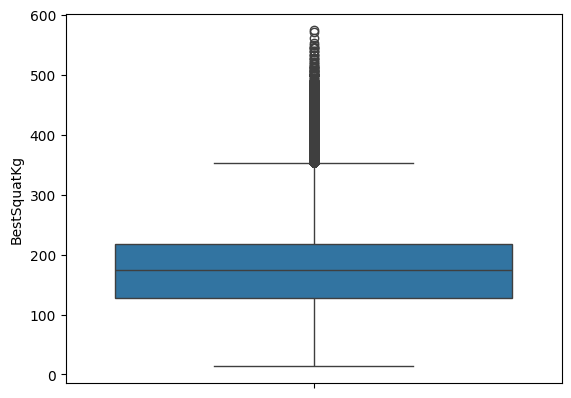

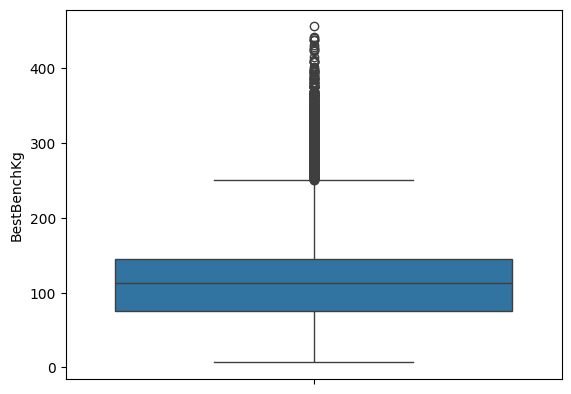

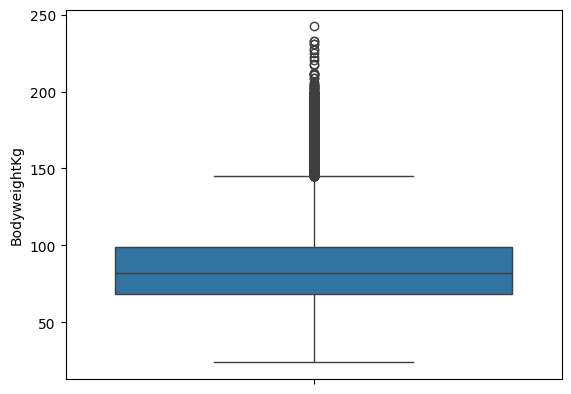

In [18]:
for i in num_col:
  sns.boxplot(df[i])
  plt.show()


Check Upper limit and lower limit of all num col

In [19]:
for i in num_col:
  q3 = df[i].quantile(0.75)
  q1 = df[i].quantile(0.25)
  iqr = q3 - q1
  ul = q3 + 1.5* iqr
  ll = q1 - 1.5 *iqr

  print(f'column {i}')
  print('Upper limit:' , ul)
  print('Lower limit:' , ll)

  # remove the outliers

  df = df[(df[i] >= ll) & (df[i] <= ul)]

column BestSquatKg
Upper limit: 353.04999999999995
Lower limit: -7.829999999999984
column BestBenchKg
Upper limit: 244.7
Lower limit: -26.819999999999993
column BodyweightKg
Upper limit: 144.525
Lower limit: 22.085


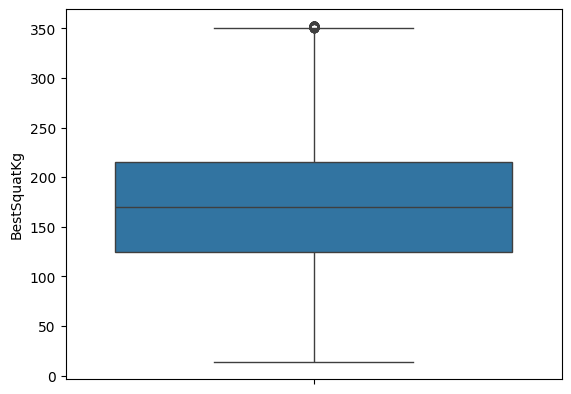

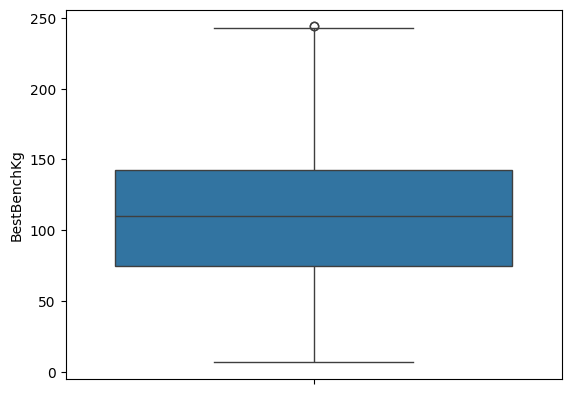

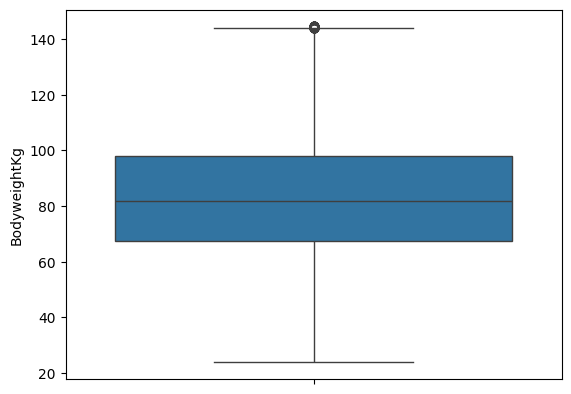

In [20]:
for i in num_col:
  sns.boxplot(df[i])
  plt.show()


###IsolationForest

In [21]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01, # contamination tells the model what proportion of the data you expect to be outliers.
    random_state=42
)

outlier_pred = iso.fit_predict(X_train[num_col])

In [22]:
outlier_pred

array([1, 1, 1, ..., 1, 1, 1])

In [23]:
outlier_df = pd.DataFrame(
    {'outlier': outlier_pred},
    index=X_train.index
)

outlier_df['outlier'].value_counts()

,count
outlier,
1,227023
-1,2293


`1` for normal data

`-1` for outliers

In [24]:
X_train_clean = X_train[outlier_df['outlier'] == 1]
y_train_clean = y_train.loc[X_train_clean.index]

In this case , with outliers and without outliers model performance is same.

In [25]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[equipment_order]))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('nom', nominal_pipeline, nominal_features),
    ('ord', ordinal_pipeline, ordinal_features)
])

##final_model creation

In [26]:
# Put all the models in a dictionary so I can loop through them
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    #'SVR': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42, n_estimators=100),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state = 42 , n_estimators = 100)
}


In [27]:
# Train every model and store the results
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])


    pipe.fit(X_train, y_train)


    y_pred = pipe.predict(X_test)

    # Calculate the metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)


    train_r2 = pipe.score(X_train, y_train)

    results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'Test R2': round(r2, 4),
        'Train R2': round(train_r2, 4)
    })

    print(name, "done")

print()

Linear Regression done
Ridge done
Lasso done
ElasticNet done
KNN Regressor done
Decision Tree done
Random Forest done
Gradient Boosting done
AdaBoost done
Extra Trees done
HistGradientBoosting done
XGBoost done



In [28]:
# comparison table, best R2 at the top
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R2', ascending=False)

results_df

,Model,MAE,MSE,RMSE,Test R2,Train R2
11,XGBoost,14.93,409.00,20.22,0.8803,0.8876
10,HistGradientBoosting,15.04,414.74,20.37,0.8786,0.8781
7,Gradient Boosting,15.20,423.80,20.59,0.8760,0.8735
6,Random Forest,15.39,444.21,21.08,0.8700,0.9792
4,KNN Regressor,16.24,477.00,21.84,0.8604,0.9042
0,Linear Regression,16.32,487.61,22.08,0.8573,0.8544
1,Ridge,16.32,487.61,22.08,0.8573,0.8544
2,Lasso,16.47,495.46,22.26,0.8550,0.8519
9,Extra Trees,16.38,523.66,22.88,0.8467,0.9966
3,ElasticNet,20.14,675.36,25.99,0.8023,0.8004


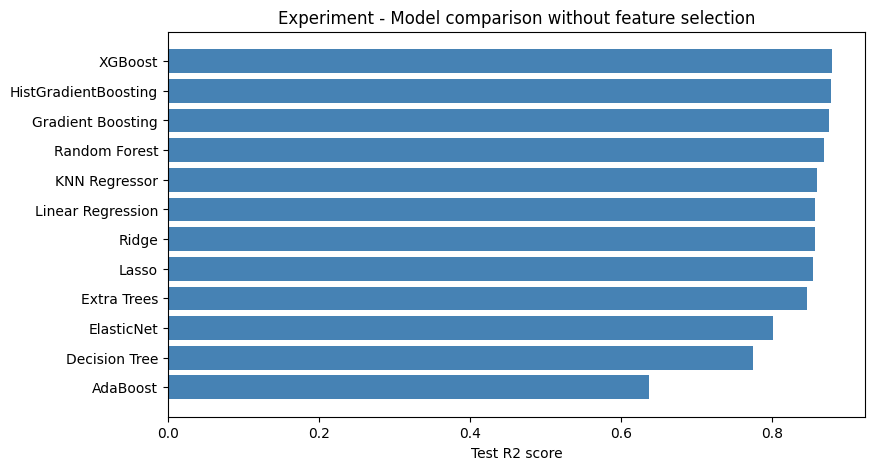

In [29]:
# same thing as a bar chart
plt.figure(figsize=(9, 5))
plt.barh(results_df['Model'], results_df['Test R2'], color='steelblue')
plt.xlabel('Test R2 score')
plt.title('Experiment - Model comparison without feature selection')
plt.gca().invert_yaxis()
plt.show()

###Hyperparameter Tuning according to model hyperparameter

In [30]:
# Small search space -> GridSearchCV
params_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

params_tree = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 10, 20],
    'model__min_samples_leaf': [1, 5, 10]
}

# Large search space -> RandomizedSearchCV
params_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

params_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5],
    'model__subsample': [0.8, 1.0]
}

params_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 1.5, 2]
}


In [31]:

models_to_tune = [
    ('Ridge', Ridge(), params_ridge, 'grid'),
    ('Decision Tree', DecisionTreeRegressor(random_state=42), params_tree, 'grid'),
    ('Random Forest', RandomForestRegressor(random_state=42), params_rf, 'random'),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42), params_gb, 'random'),
    ('XGBoost' , XGBRegressor(random_state = 42) ,params_xgb , 'random' )
]

for name, model, params, method in models_to_tune:
    print(name, "->", method, "search")

Ridge -> grid search
Decision Tree -> grid search
Random Forest -> random search
Gradient Boosting -> random search
XGBoost -> random search


In [32]:
tuned_results = []
best_models = {}

for name, model, params, method in models_to_tune:

    print("Tuning:", name, "...")

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])


    if method == 'grid':
        search = GridSearchCV(pipe, params, cv=5, scoring='r2', n_jobs=-1)
    else:
        search = RandomizedSearchCV(pipe, params, n_iter=15, cv=5, scoring='r2',
                                    random_state=42, n_jobs=-1)


    search.fit(X_train, y_train)


    y_pred = search.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'Best CV R2': round(search.best_score_, 4),
        'Test R2': round(test_r2, 4),
        'Test RMSE': round(test_rmse, 2),
        'Test MAE': round(test_mae, 2)
    })

    best_models[name] = search

    print("   Best CV R2:", round(search.best_score_, 4))
    print("   Test R2   :", round(test_r2, 4))

Tuning: Ridge ...
   Best CV R2: 0.8544
   Test R2   : 0.8573
Tuning: Decision Tree ...
   Best CV R2: 0.8704
   Test R2   : 0.8742
Tuning: Random Forest ...


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


   Best CV R2: 0.8787
   Test R2   : 0.8824
Tuning: Gradient Boosting ...
   Best CV R2: 0.876
   Test R2   : 0.88
Tuning: XGBoost ...
   Best CV R2: 0.877
   Test R2   : 0.8807


In [33]:
# Show the best parameters found for each model
for name in best_models:
    print(name)
    print("  Best parameters:", best_models[name].best_params_)
    print("  Best CV score  :", round(best_models[name].best_score_, 4))

Ridge
  Best parameters: {'model__alpha': 10}
  Best CV score  : 0.8544
Decision Tree
  Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
  Best CV score  : 0.8704
Random Forest
  Best parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 15}
  Best CV score  : 0.8787
Gradient Boosting
  Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.2}
  Best CV score  : 0.876
XGBoost
  Best parameters: {'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}
  Best CV score  : 0.877


In [34]:
# Compare before tuning and after tuning
tuned_df = pd.DataFrame(tuned_results)

# Get the before-tuning scores for the same models
before = results_df[['Model', 'Test R2']].rename(columns={'Test R2': 'Before Tuning'})
after = tuned_df[['Model', 'Test R2', 'Best CV R2']].rename(columns={'Test R2': 'After Tuning'})

comparison = pd.merge(before, after, on='Model')
comparison['Improvement'] = (comparison['After Tuning'] - comparison['Before Tuning']).round(4)
comparison = comparison.sort_values('After Tuning', ascending=False)

print("Effect of hyperparameter tuning")
comparison

Effect of hyperparameter tuning


,Model,Before Tuning,After Tuning,Best CV R2,Improvement
2,Random Forest,0.8700,0.8824,0.8787,0.0124
0,XGBoost,0.8803,0.8807,0.8770,0.0004
1,Gradient Boosting,0.8760,0.8800,0.8760,0.0040
4,Decision Tree,0.7753,0.8742,0.8704,0.0989
3,Ridge,0.8573,0.8573,0.8544,0.0000


###Final Pipeline with **XGBRegressor**

In [35]:
# Build the final pipeline using model XGBoost
final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(random_state=42,
                           subsample=1.0,
                           reg_lambda= 1,
                           reg_alpha= 0.01,
                           n_estimators= 300,
                           min_child_weight= 5,
                           max_depth= 7,
                           learning_rate= 0.05,
                           gamma= 0,
                           colsample_bytree= 0.7
                           ))
])

final_pipeline.fit(X_train, y_train)

final_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BestSquatKg', 'BestBenchKg',
                                                   'BodyweightKg']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex']),
                                                 ('ord...
                              feature_types=None, feature_weights=None, gamma=0,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=300,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [36]:

y_pred_final = final_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("MAE :", round(final_mae, 2), "kg")
print("MSE :", round(final_mse, 2))
print("RMSE:", round(final_rmse, 2), "kg")
print("R2  :", round(final_r2, 4))

n = len(X_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - final_r2) * ((n - 1) / (n - p - 1))
print('Adjusted R2:', round(adjusted_r2, 4))

MAE : 14.9 kg
MSE : 407.46
RMSE: 20.19 kg
R2  : 0.8807
Adjusted R2: 0.8807


In [37]:
import joblib
joblib.dump(final_pipeline , 'final_model.pkl')
print('Model saved Successfully.')

Model saved Successfully.
